# Import necessary libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import lightgbm as lgb
from datetime import datetime


In [2]:
%matplotlib inline

In [3]:
# Load the dataset
df = pd.read_csv('Last.fm_data.csv', index_col=0)

# Display first few rows
print("Dataset Preview:")
print(df.head())

# Check dataset info
print("\nDataset Info:")
print(df.info())

Dataset Preview:
  Username           Artist                          Track  \
0  Babs_05  Isobel Campbell     The Circus Is Leaving Town   
1  Babs_05  Isobel Campbell                   Dusty Wreath   
2  Babs_05  Isobel Campbell     Honey Child What Can I Do?   
3  Babs_05  Isobel Campbell  It's Hard To Kill A Bad Thing   
4  Babs_05  Isobel Campbell                Saturday's Gone   

                       Album         Date    Time  
0  Ballad of the Broken Seas  31 Jan 2021   23:36  
1  Ballad of the Broken Seas  31 Jan 2021   23:32  
2  Ballad of the Broken Seas  31 Jan 2021   23:28  
3  Ballad of the Broken Seas  31 Jan 2021   23:25  
4  Ballad of the Broken Seas  31 Jan 2021   23:21  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 166153 entries, 0 to 265628
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Username  166153 non-null  object
 1   Artist    166153 non-null  object
 2   Track     166153 

# Check for missing values

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Username     0
Artist       0
Track        0
Album       12
Date         0
Time         0
dtype: int64


# Convert 'Date' and 'Time' to datetime

In [5]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d %b %Y %H:%M')
df['Hour'] = df['Datetime'].dt.hour
df['Day'] = df['Datetime'].dt.day
df['Weekday'] = df['Datetime'].dt.weekday

# Drop original Date and Time columns
df = df.drop(['Date', 'Time'], axis=1)

# --- Exploratory Data Analysis ---

# Top Artists by Listen Count

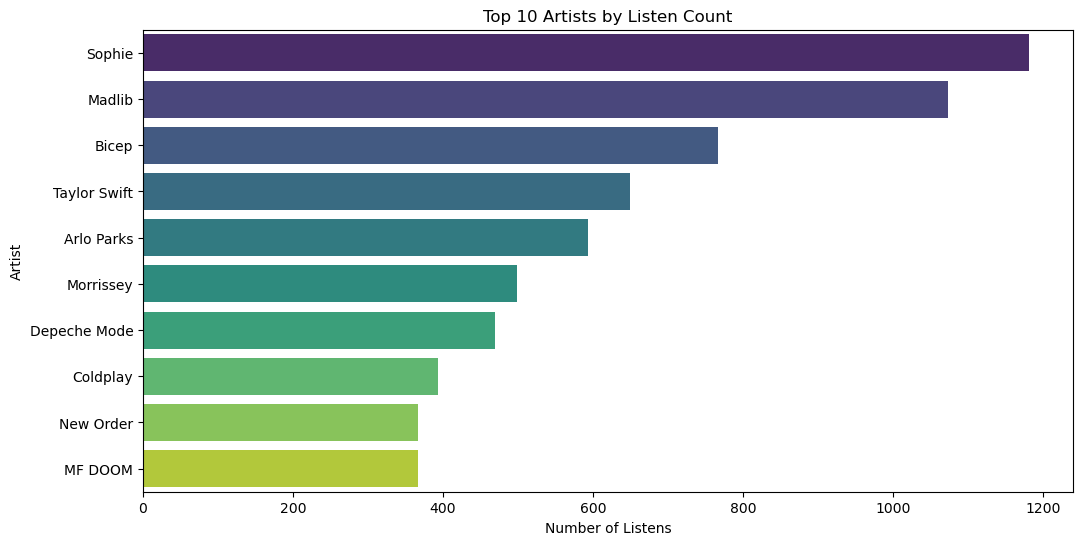

In [6]:
top_artists = df['Artist'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')
plt.title('Top 10 Artists by Listen Count')
plt.xlabel('Number of Listens')
plt.ylabel('Artist')
plt.show()

# Listening Patterns by Hour

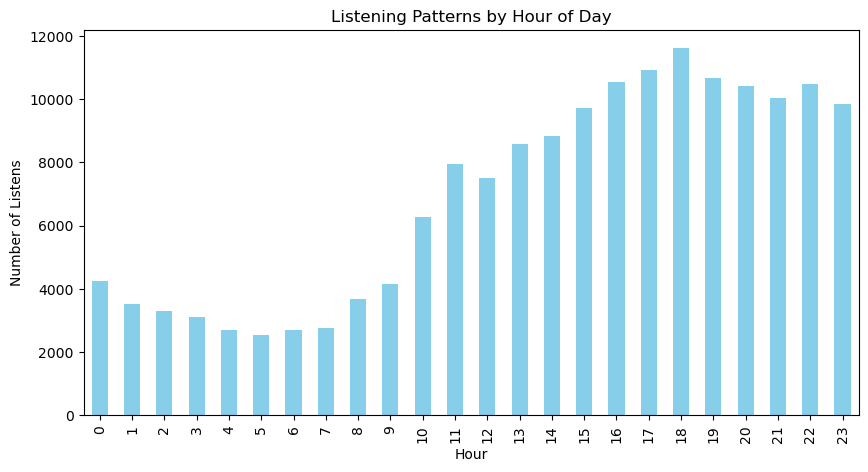

In [7]:
hourly_listens = df['Hour'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
hourly_listens.plot(kind='bar', color='skyblue')
plt.title('Listening Patterns by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Listens')
plt.show()

# Listening Patterns by Weekday

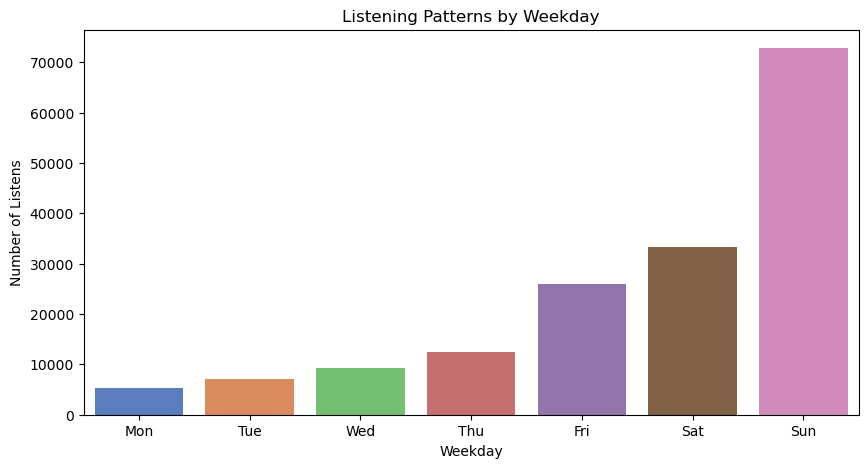

In [8]:
weekday_listens = df['Weekday'].value_counts().sort_index()
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_listens.index, y=weekday_listens.values, palette='muted')
plt.xticks(ticks=range(7), labels=weekday_names)
plt.title('Listening Patterns by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Number of Listens')
plt.show()

# Top Albums by Listen Count

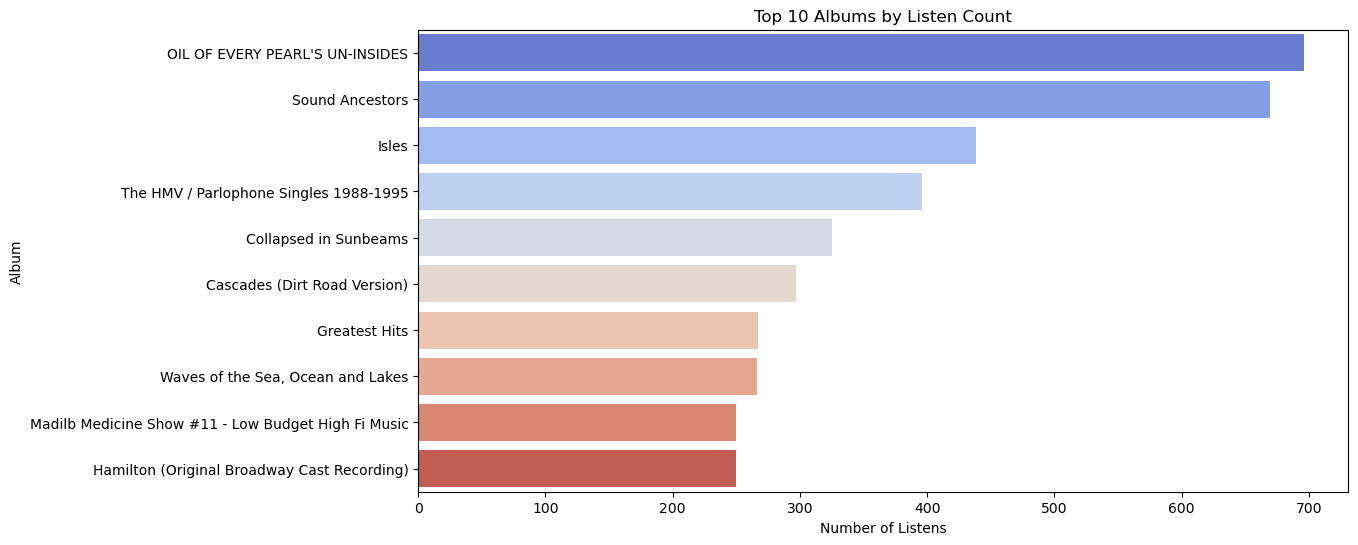

In [9]:

top_albums = df['Album'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_albums.values, y=top_albums.index, palette='coolwarm')
plt.title('Top 10 Albums by Listen Count')
plt.xlabel('Number of Listens')
plt.ylabel('Album')
plt.show()

# --- Feature Engineering for Predictive Modeling ---

As there is no meaningful thing to predict with this dataset, I make up a target which is basically non-sense just for demonstration of Feature Engineering for Predictive Modeling purposes.  

In [10]:

# Aggregate listens per artist to predict artist popularity
artist_listens = df.groupby('Artist').size().reset_index(name='Listen_Count')

# Merge listen count back to main dataframe
df = df.merge(artist_listens, on='Artist', how='left')

# Create additional features
df['Is_Weekend'] = df['Weekday'].apply(lambda x: 1 if x >= 5 else 0)
df['Hour_Bin'] = pd.cut(df['Hour'], bins=[0, 6, 12, 18, 24], labels=['Night', 'Morning', 'Afternoon', 'Evening'])

# Encode categorical variables
le_artist = LabelEncoder()
df['Artist_Encoded'] = le_artist.fit_transform(df['Artist'])

le_album = LabelEncoder()
df['Album_Encoded'] = le_album.fit_transform(df['Album'])

# --- Predictive Modeling: Predicting Artist Popularity ---

# Features and target
features = ['Hour', 'Day', 'Weekday', 'Is_Weekend', 'Artist_Encoded', 'Album_Encoded']
target = 'Listen_Count'

# Split data
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluate Random Forest
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)
print("\nRandom Forest Results:")
print(f"Mean Squared Error: {rf_mse:.2f}")
print(f"R2 Score: {rf_r2:.2f}")



Random Forest Results:
Mean Squared Error: 134.71
R2 Score: 1.00


# Feature Importance (RF)

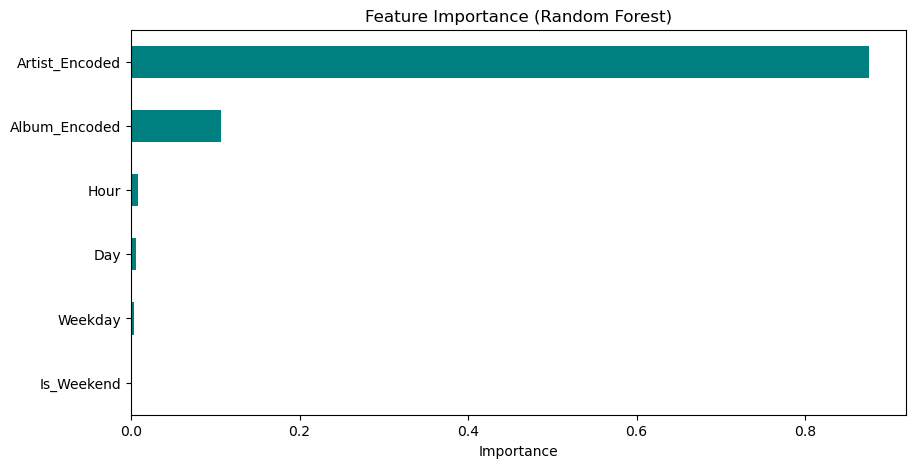

In [11]:

feature_importance = pd.Series(rf_model.feature_importances_, index=features)
plt.figure(figsize=(10, 5))
feature_importance.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()


# LightGBM Regressor

In [12]:
lgb_model = lgb.LGBMRegressor(n_estimators=100, random_state=42)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

# Evaluate LightGBM
lgb_mse = mean_squared_error(y_test, y_pred_lgb)
lgb_r2 = r2_score(y_test, y_pred_lgb)
print("\nLightGBM Results:")
print(f"Mean Squared Error: {lgb_mse:.2f}")
print(f"R2 Score: {lgb_r2:.2f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001097 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 575
[LightGBM] [Info] Number of data points in the train set: 132922, number of used features: 6
[LightGBM] [Info] Start training from score 85.143859

LightGBM Results:
Mean Squared Error: 4455.85
R2 Score: 0.84


# Feature Importance (LightGBM)

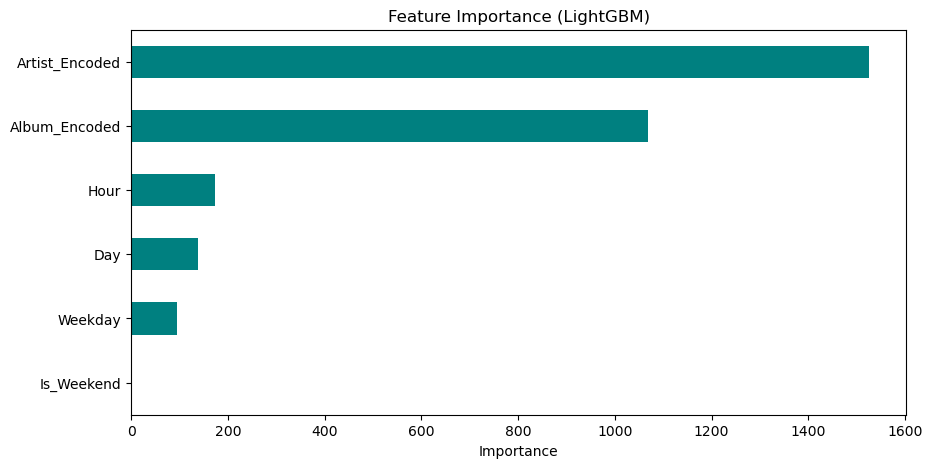

In [13]:

feature_importance = pd.Series(lgb_model.feature_importances_, index=features)
plt.figure(figsize=(10, 5))
feature_importance.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance (LightGBM)')
plt.xlabel('Importance')
plt.show()
